Using device: cpu
Using Colab cache for faster access to the 'dataset' dataset.
Downloaded to: /kaggle/input/dataset
dataset/  (0 files)
  val/  (0 files)
    OSCC/  (92 files)
    Normal/  (28 files)
  test/  (0 files)
    OSCC/  (95 files)
    Normal/  (31 files)
  train/  (0 files)
    OSCC/  (2511 files)
    Normal/  (2435 files)
Total images found: 5192
Cancer (OSCC): 2698
Normal: 2494
Dataset mean: [0.53808228 0.50379157 0.71690328]
Dataset std : [0.19190479 0.21539343 0.15295663]
Train: 3634  Val: 779  Test: 779
Train class balance -> cancer: 1888, normal: 1746
Batch shape: torch.Size([32, 3, 128, 128]) | labels: tensor([0., 0., 0., 0., 0., 1., 1., 0.])
CancerCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

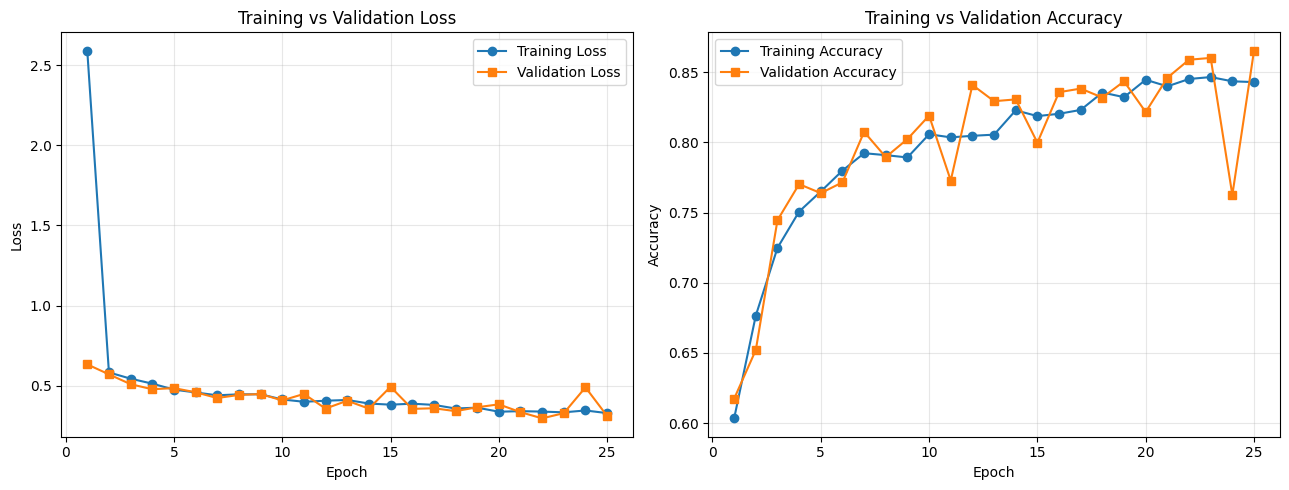

Learning curves saved as 'learning_curve.png'
Test accuracy: 0.879


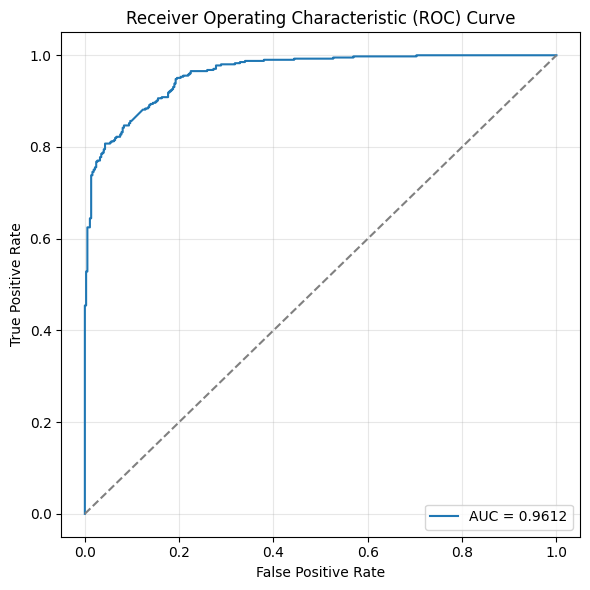

ROC-AUC Score: 0.9612
ROC curve saved as 'roc_curve.png'


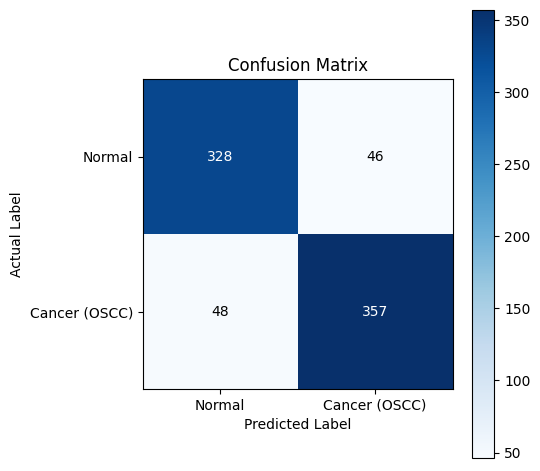

Confusion Matrix saved as 'confusion_matrix.png'


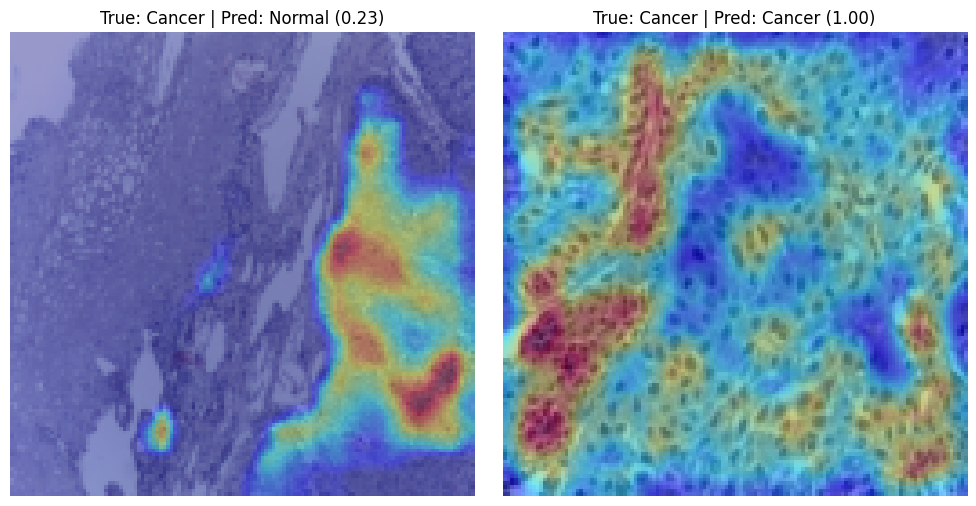

Grad-CAM visualization saved as 'gradcam.png'
Diagnostics complete! Files saved:
  [OK] learning_curve.png
  [OK] roc_curve.png
  [OK] confusion_matrix.png
  [OK] gradcam.png
  [OK] best_model.pt

Final test accuracy: 0.879
Final ROC-AUC:       0.9612


In [ ]:
# =============================================================================
# Image-Based Cancer Diagnosis Using Convolutional Neural Networks (CNNs)
#import core libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#import dataset
import kagglehub

kaggle_path = kagglehub.dataset_download("ashenafifasilkebede/dataset")
print("Downloaded to:", kaggle_path)

for root, dirs, files in os.walk(kaggle_path):
    depth = root.replace(kaggle_path, "").count(os.sep)
    if depth <= 2:
        print("  " * depth + os.path.basename(root) + f"/  ({len(files)} files)")

CLASS_TO_LABEL = {"normal": 0, "oscc": 1}

filepaths = []
labels = []

for root, dirs, files in os.walk(kaggle_path):
    folder_key = os.path.basename(root).lower()
    if folder_key not in CLASS_TO_LABEL:
        continue
    label = CLASS_TO_LABEL[folder_key]
    for fname in files:
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            filepaths.append(os.path.join(root, fname))
            labels.append(label)

print(f"Total images found: {len(filepaths)}")
print(f"Cancer (OSCC): {sum(labels)}")
print(f"Normal: {len(labels) - sum(labels)}")

#compute dataset mean
IMG_SIZE = 128

def compute_mean_std(paths, sample_size=250):
    sample = random.sample(paths, min(sample_size, len(paths)))
    pixel_sum = np.zeros(3)
    pixel_sq_sum = np.zeros(3)
    n_pixels = 0

    for p in sample:
        img = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        arr = np.asarray(img, dtype=np.float64) / 255.0
        pixel_sum += arr.sum(axis=(0, 1))
        pixel_sq_sum += (arr ** 2).sum(axis=(0, 1))
        n_pixels += arr.shape[0] * arr.shape[1]

    mean = pixel_sum / n_pixels
    std = np.sqrt(pixel_sq_sum / n_pixels - mean ** 2)
    return mean, std

DATA_MEAN, DATA_STD = compute_mean_std(filepaths)
print("Dataset mean:", DATA_MEAN)
print("Dataset std :", DATA_STD)

import torchvision.transforms as T

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=DATA_MEAN, std=DATA_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=DATA_MEAN, std=DATA_STD),
])


class OralCancerDataset(Dataset):
    """Image-folder-style dataset for the oral cancer histopathology images."""

    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

#stratified train/validation/test (70/15/15)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_paths)}  Val: {len(val_paths)}  Test: {len(test_paths)}")
print(f"Train class balance -> cancer: {sum(train_labels)}, normal: {len(train_labels)-sum(train_labels)}")

train_ds = OralCancerDataset(train_paths, train_labels, transform=train_transform)
val_ds = OralCancerDataset(val_paths, val_labels, transform=eval_transform)
test_ds = OralCancerDataset(test_paths, test_labels, transform=eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# quick sanity check
imgs, lbls = next(iter(train_loader))
print("Batch shape:", imgs.shape, "| labels:", lbls[:8])

class CancerCNN(nn.Module):
    def __init__(self, img_size=IMG_SIZE, dropout_p=0.4):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(dropout_p)

        # 3 pooling layers -> spatial dims shrink by 2^3 = 8
        reduced = img_size // 8
        self.fc1 = nn.Linear(128 * reduced * reduced, 256)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x


model = CancerCNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

EPOCHS = 25


def run_epoch(loader, model, criterion, optimizer=None):
    """One pass over `loader`. If optimizer is given we're training, else eval."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    torch.set_grad_enabled(is_train)
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device).unsqueeze(1)

        if is_train:
            optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, lbls)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == lbls).sum().item()
        total += imgs.size(0)

    torch.set_grad_enabled(True)
    return total_loss / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

#learning curves
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f}")

print("\nTraining done. Best val loss:", round(best_val_loss, 4))

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Training Loss")
axes[0].plot(epochs_range, history["val_loss"], marker="s", label="Validation Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Training Accuracy")
axes[1].plot(epochs_range, history["val_acc"], marker="s", label="Validation Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150)
plt.show()
print("Learning curves saved as 'learning_curve.png'")

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).cpu().numpy().flatten()
        all_probs.extend(outputs.tolist())
        all_true.extend(lbls.numpy().tolist())

all_probs = np.array(all_probs)
all_true = np.array(all_true)
all_preds = (all_probs >= 0.5).astype(int)

test_acc = (all_preds == all_true).mean()
print(f"Test accuracy: {test_acc:.3f}")

#roc_curve
fpr, tpr, thresholds = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("ROC curve saved as 'roc_curve.png'")

#confusion_matrix
cm = confusion_matrix(all_true, all_preds)
class_names = ["Normal", "Cancer (OSCC)"]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion Matrix saved as 'confusion_matrix.png'")

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, input_tensor):
        self.model.zero_grad()
        output = self.model(input_tensor)
        output.backward()

        pooled_gradients = self.gradients.mean(dim=(0, 2, 3))
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]

        heatmap = activations.mean(dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (heatmap.max() + 1e-8)
        return heatmap, output.item()


gradcam = GradCAM(model, model.conv3)

sample_idxs = random.sample(range(len(test_ds)), 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, idx in zip(axes, sample_idxs):
    img_tensor, true_label = test_ds[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    heatmap, pred_prob = gradcam(input_tensor)
    heatmap_resized = np.array(Image.fromarray(np.uint8(heatmap * 255)).resize((IMG_SIZE, IMG_SIZE)))

    disp_img = img_tensor.numpy().transpose(1, 2, 0)
    disp_img = disp_img * np.array(DATA_STD) + np.array(DATA_MEAN)
    disp_img = np.clip(disp_img, 0, 1)

    ax.imshow(disp_img)
    ax.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    pred_label = "Cancer" if pred_prob >= 0.5 else "Normal"
    true_label_str = "Cancer" if true_label == 1 else "Normal"
    ax.set_title(f"True: {true_label_str} | Pred: {pred_label} ({pred_prob:.2f})")
    ax.axis("off")

plt.tight_layout()
plt.savefig("gradcam.png", dpi=150)
plt.show()
print("Grad-CAM visualization saved as 'gradcam.png'")

print("Diagnostics complete! Files saved:")
for f in ["learning_curve.png", "roc_curve.png", "confusion_matrix.png", "gradcam.png", "best_model.pt"]:
    exists = "OK" if os.path.exists(f) else "MISSING"
    print(f"  [{exists}] {f}")

print(f"\nFinal test accuracy: {test_acc:.3f}")
print(f"Final ROC-AUC:       {roc_auc:.4f}")